In [12]:
import pandas as pd

df_test = pd.read_csv('electricity_consumption_and_production.csv', nrows=2)
print("колонки у файлі:")
print(df_test.columns.tolist())

колонки у файлі:
['DateTime', 'Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('electricity_consumption_and_production.csv', 
                 parse_dates=['DateTime'], 
                 index_col='DateTime')

series = df['Consumption']

#ресемплінг

series = series[~series.index.duplicated(keep='first')]
daily_series = series.resample('D').mean()

daily_series = daily_series.interpolate(method='linear')

print(f"Розмір: {len(daily_series)} днів")
daily_series.head()

Розмір: 2270 днів


DateTime
2019-01-01    5924.478261
2019-01-02    6322.041667
2019-01-03    7254.083333
2019-01-04    7635.083333
2019-01-05    7423.521739
Freq: D, Name: Consumption, dtype: float64

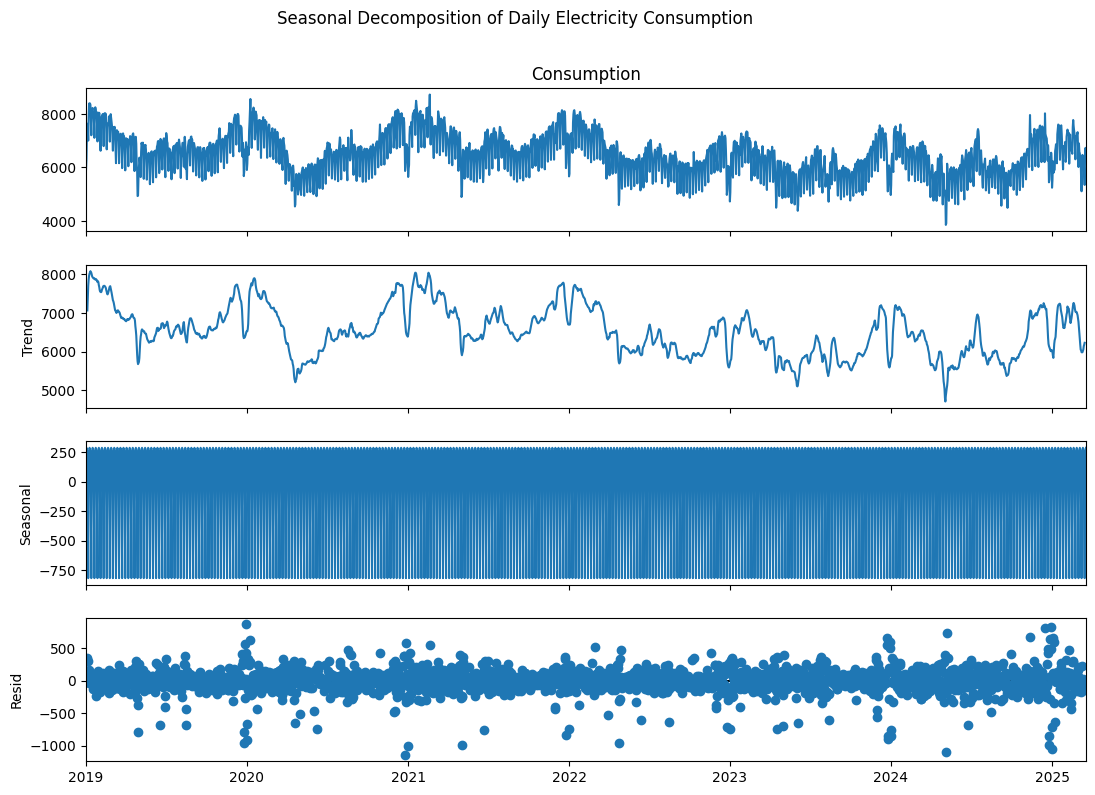

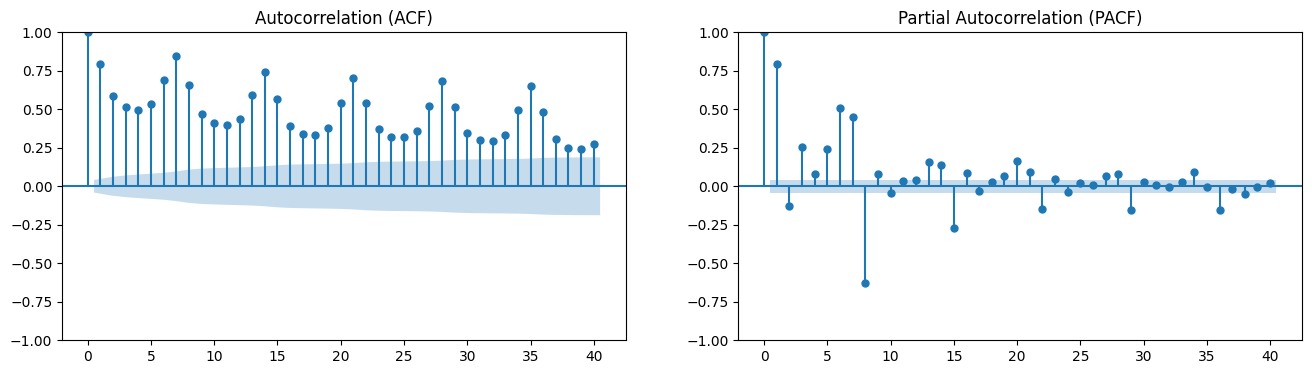

ADF Statistic: -3.3878
p-value: 0.0114
Ряд ймовірно СТАЦІОНАРНИЙ


In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

decomp = seasonal_decompose(daily_series, period=7, model='additive')
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Daily Electricity Consumption", y=1.02)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily_series, lags=40, ax=axes[0], title="Autocorrelation (ACF)")
plot_pacf(daily_series, lags=40, ax=axes[1], title="Partial Autocorrelation (PACF)")
plt.show()

adf_result = adfuller(daily_series)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("Ряд ймовірно СТАЦІОНАРНИЙ")
else:
    print("Ряд НЕСТАЦІОНАРНИЙ")

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

test_size = 45
train = daily_series.iloc[:-test_size]
test = daily_series.iloc[-test_size:]

model = ExponentialSmoothing(train, 
                             seasonal='add', 
                             seasonal_periods=7, 
                             trend='add', 
                             damped_trend=True)
fit_model = model.fit()

forecast_45 = fit_model.forecast(45)
forecast_15 = forecast_45.iloc[:15]
forecast_30 = forecast_45.iloc[:30]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def print_metrics(horizon_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    print(f"Прогноз на {horizon_name} днів")
    print(f"MAE:  {mae:.2f} MW")
    print(f"MAPE: {mape:.2f}%\n")

print_metrics("15", test.iloc[:15], forecast_15)
print_metrics("30", test.iloc[:30], forecast_30)
print_metrics("45", test, forecast_45)

Прогноз на 15 днів
MAE:  304.22 MW
MAPE: 4.43%

Прогноз на 30 днів
MAE:  267.38 MW
MAPE: 3.89%

Прогноз на 45 днів
MAE:  538.23 MW
MAPE: 8.55%



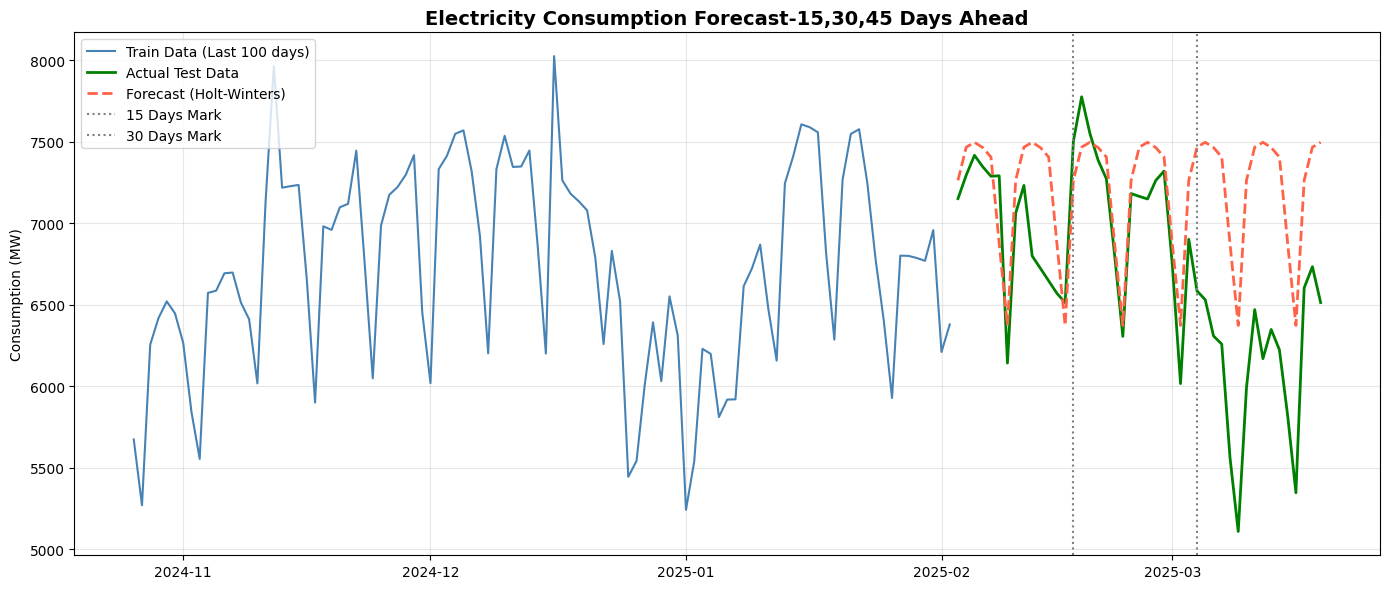

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(train.index[-100:], train.iloc[-100:], label='Train Data (Last 100 days)', color='steelblue')
plt.plot(test.index, test, label='Actual Test Data', color='green', linewidth=2)
plt.plot(forecast_45.index, forecast_45, label='Forecast (Holt-Winters)', color='tomato', linestyle='--', linewidth=2)

plt.axvline(x=test.index[14], color='gray', linestyle=':', label='15 Days Mark')
plt.axvline(x=test.index[29], color='gray', linestyle=':', label='30 Days Mark')

plt.title("Electricity Consumption Forecast-15,30,45 Days Ahead", fontsize=14, fontweight='bold')
plt.ylabel("Consumption (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()